In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

from itertools import product

# Ground state preparation

In [2]:
num_sites = [3, 5, 8, 12]
couplings = [0, 0.5, 2, 5]
dd_enabled = ['std', 'dd']
folds = [1, 3, 5]

ref_data = dict()
for (n, h) in product(num_sites, couplings) :
    ref_energy = np.load(f'data/ref_{n}_{h}.npy')
    ref_data[(n, h)] = ref_energy

obs_data = dict()
for (n, h, dd_str, f) in product(num_sites, couplings, dd_enabled, folds) :
    energy = np.load(f'data/energy_{n}_{h}_{dd_str}_{f}.npy')
    obs_data[(n, h, dd_str, f)] = energy

# print(ref_data, obs_data)

## No error mitigation.

In [3]:
baseline = dict()
for (n, h) in product(num_sites, couplings) :
    baseline[(n, h)] = np.abs(obs_data[(n, h, 'std', 1)] - ref_data[(n, h)])

# print(baseline)

## Dynamical Decoupling (DD)

In [4]:
ddem = dict()
ddim = dict()
for (n, h) in product(num_sites, couplings) :
    ddem[(n, h)] = np.abs(obs_data[(n, h, 'dd', 1)] - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddem[(n, h)]/baseline[(n, h)])
    ddim[(n, h)] = float(percentage_improvement[0])
    print(f"n={n:3}, h={h:5}:\t\t {ddim[(n, h)]:05.2f}")

n=  3, h=    0:		 31.69
n=  3, h=  0.5:		 30.18
n=  3, h=    2:		 18.90
n=  3, h=    5:		 26.38
n=  5, h=    0:		 26.58
n=  5, h=  0.5:		 17.41
n=  5, h=    2:		 17.67
n=  5, h=    5:		 02.00
n=  8, h=    0:		 15.23
n=  8, h=  0.5:		 16.72
n=  8, h=    2:		 14.39
n=  8, h=    5:		 00.12
n= 12, h=    0:		 18.73
n= 12, h=  0.5:		 12.30
n= 12, h=    2:		 06.79
n= 12, h=    5:		 09.69


## Zero-Noise Extrapolation (ZNE)
We experiment with both exponential curve fitting and Richardson (polynomial) extrapolation
and choose polynomial fitting as the better alternative.

In [5]:
def zne_exp(exp_vals, lambdas=(1.0,3.0,5.0)) :
    def exponential_model(l, A, B, C):
        return A + B * np.exp(-C * l)
    popt, _ = curve_fit(exponential_model, lambdas, exp_vals)
    zne_exponential = popt[0] + popt[1] # Equivalent to exponential_model(0, *popt)
    return zne_exponential

def zne_poly(exp_vals, lambdas=(1.0,3.0,5.0)) :
    coeffs = np.polyfit(lambdas, exp_vals, deg=len(lambdas)-1)
    zne_richardson = np.polyval(coeffs, 0)
    return zne_richardson

In [6]:
zneem = dict()
zneim = dict()

for (n, h) in product(num_sites, couplings) :
    zne_val = zne_poly([obs_data[(n, h, 'std', 1)], obs_data[(n, h, 'std', 3)], obs_data[(n, h, 'std', 5)]])
    zneem[(n, h)] = np.abs(zne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-zneem[(n, h)]/baseline[(n, h)])
    zneim[(n, h)] = float(percentage_improvement[0])
    print(f"n={n:3}, h={h:5}:\t\t {zneim[(n, h)]:05.2f}")

n=  3, h=    0:		 36.13
n=  3, h=  0.5:		 65.91
n=  3, h=    2:		 66.34
n=  3, h=    5:		 50.39
n=  5, h=    0:		 65.01
n=  5, h=  0.5:		 77.60
n=  5, h=    2:		 89.94
n=  5, h=    5:		 87.95
n=  8, h=    0:		 77.26
n=  8, h=  0.5:		 77.60
n=  8, h=    2:		 96.24
n=  8, h=    5:		 50.46
n= 12, h=    0:		 54.56
n= 12, h=  0.5:		 72.64
n= 12, h=    2:		 55.16
n= 12, h=    5:		 59.66


## Both methods (ZNE+DD)

In [7]:
ddzneem = dict()
ddzneim = dict()

for (n, h) in product(num_sites, couplings) :
    ddzne_val = zne_poly([obs_data[(n, h, 'dd', 1)], obs_data[(n, h, 'dd', 3)], obs_data[(n, h, 'dd', 5)]])
    ddzneem[(n, h)] = np.abs(ddzne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddzneem[(n, h)]/baseline[(n, h)])
    ddzneim[(n, h)] = float(percentage_improvement[0])
    print(f"n={n:3}, h={h:5}:\t\t {ddzneim[(n, h)]:05.2f}")

n=  3, h=    0:		 68.32
n=  3, h=  0.5:		 67.71
n=  3, h=    2:		 61.94
n=  3, h=    5:		 75.18
n=  5, h=    0:		 77.77
n=  5, h=  0.5:		 94.00
n=  5, h=    2:		 85.92
n=  5, h=    5:		 64.12
n=  8, h=    0:		 78.72
n=  8, h=  0.5:		 74.09
n=  8, h=    2:		 92.39
n=  8, h=    5:		 90.68
n= 12, h=    0:		 73.48
n= 12, h=  0.5:		 72.47
n= 12, h=    2:		 74.13
n= 12, h=    5:		 63.15


## Plotting results

In [8]:
color_dd     = '#66c2a5'
color_zne    = '#fc8d62'
color_dd_zne = '#8da0cb'

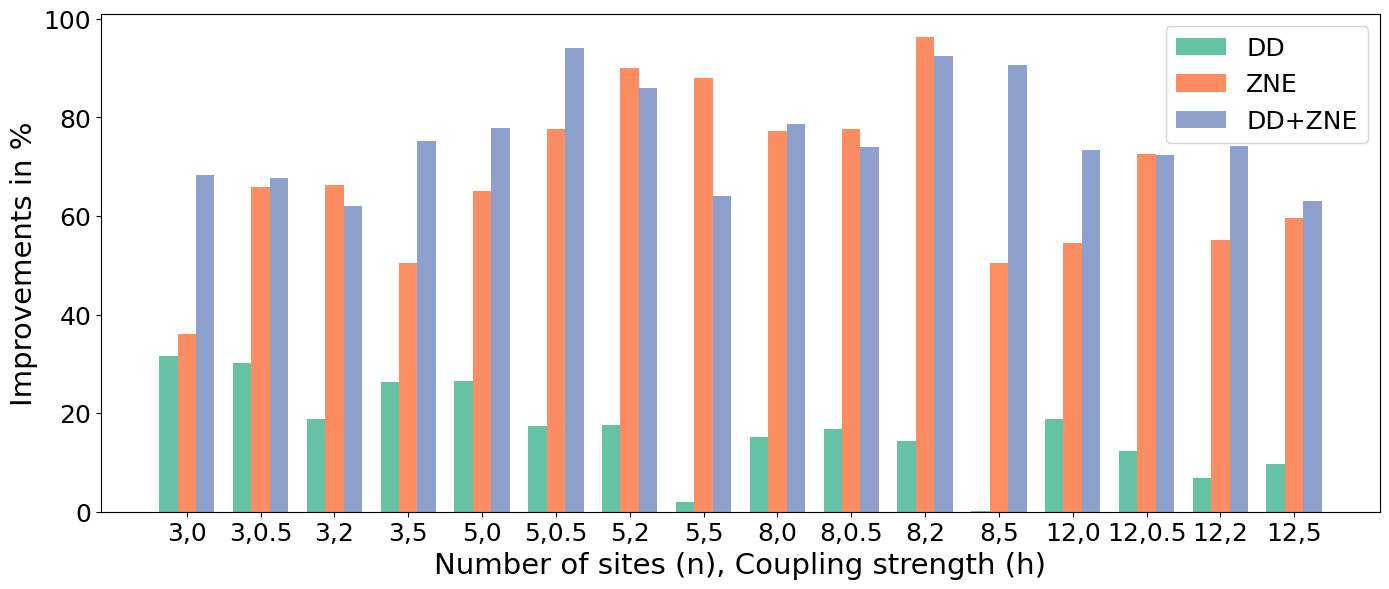

In [9]:
# 1. Prepare your 3 sets of 16 values
dd_values = [ddim[(n, h)] for (n, h) in product(num_sites, couplings)]
zne_values = [zneim[(n, h)] for (n, h) in product(num_sites, couplings)]
dd_zne_values = [ddzneim[(n, h)] for (n, h) in product(num_sites, couplings)]

# Labels for the 16 groups
groups = [f'{n},{h}' for (n, h) in product(num_sites, couplings)]

# 2. Set up positions
x = np.arange(len(groups))  # The label locations
width = 0.25  # The width of the individual bars

fig, ax = plt.subplots(figsize=(14, 6))

# 3. Create the bars
# We offset each bar by the width to keep them grouped
rects1 = ax.bar(x - width, dd_values, width, label='DD', color=color_dd)
rects2 = ax.bar(x, zne_values, width, label='ZNE', color=color_zne)
rects3 = ax.bar(x + width, dd_zne_values, width, label='DD+ZNE', color=color_dd_zne)

ax.set_xlabel('Number of sites (n), Coupling strength (h)', fontsize=21)
ax.set_ylabel('Improvements in %', fontsize=21)
# ax.set_title('Comparison of EM techniques for Heisenberg Hamiltonian ground state preparation', fontsize=21)
ax.set_xticks(x)
ax.set_xticklabels(groups) # Rotated for better readability
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('heisenberg_gsp.pdf')
plt.show()

# Hamiltonian simulation

In [10]:
num_sites = [5, 12]
couplings = [0.5, 5]
dd_enabled = ['std', 'dd']
folds = [1, 3, 5]

ref_data = dict()
for (n, h) in product(num_sites, couplings) :
    ref_energy = np.load(f'data/evo_ref_{n}_{h}.npy')
    ref_data[(n, h)] = ref_energy

obs_data = dict()
for (n, h, dd_str, f) in product(num_sites, couplings, dd_enabled, folds) :
    energy = np.load(f'data/evo_energy_{n}_{h}_{dd_str}_{f}.npy')
    obs_data[(n, h, dd_str, f)] = energy

# print(ref_data, obs_data)

## No error mitigation.

In [11]:
baseline = dict()
for (n, h) in product(num_sites, couplings) :
    baseline[(n, h)] = np.abs(obs_data[(n, h, 'std', 1)] - ref_data[(n, h)])

# print(baseline)

## Dynamical Decoupling (DD)

In [12]:
ddem = dict()
ddim = dict()
for (n, h) in product(num_sites, couplings) :
    ddem[(n, h)] = np.abs(obs_data[(n, h, 'dd', 1)] - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddem[(n, h)]/baseline[(n, h)])
    ddim[(n, h)] = float(percentage_improvement)
    print(f"n={n:3}, h={h:5}:\t\t {ddim[(n, h)]:05.2f}")

n=  5, h=  0.5:		 01.53
n=  5, h=    5:		 11.50
n= 12, h=  0.5:		 -3.98
n= 12, h=    5:		 15.24


## Zero-Noise Extrapolation (ZNE)
We experiment with both exponential curve fitting and Richardson (polynomial) extrapolation
and choose polynomial fitting as the better alternative.

In [13]:
zneem = dict()
zneim = dict()

for (n, h) in product(num_sites, couplings) :
    zne_val = zne_poly([obs_data[(n, h, 'std', 1)], obs_data[(n, h, 'std', 3)], obs_data[(n, h, 'std', 5)]])
    zneem[(n, h)] = np.abs(zne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-zneem[(n, h)]/baseline[(n, h)])
    zneim[(n, h)] = float(percentage_improvement)
    print(f"n={n:3}, h={h:5}:\t\t {zneim[(n, h)]:05.2f}")

n=  5, h=  0.5:		 09.34
n=  5, h=    5:		 -10.68
n= 12, h=  0.5:		 10.92
n= 12, h=    5:		 -11.29


## Both methods (ZNE+DD)

In [14]:
ddzneem = dict()
ddzneim = dict()

for (n, h) in product(num_sites, couplings) :
    ddzne_val = zne_poly([obs_data[(n, h, 'dd', 1)], obs_data[(n, h, 'dd', 3)], obs_data[(n, h, 'dd', 5)]])
    ddzneem[(n, h)] = np.abs(ddzne_val - ref_data[(n, h)])
    percentage_improvement = 100 * (1-ddzneem[(n, h)]/baseline[(n, h)])
    ddzneim[(n, h)] = float(percentage_improvement)
    print(f"n={n:3}, h={h:5}:\t\t {ddzneim[(n, h)]:05.2f}")

n=  5, h=  0.5:		 03.42
n=  5, h=    5:		 08.51
n= 12, h=  0.5:		 05.05
n= 12, h=    5:		 22.04


## Plotting results

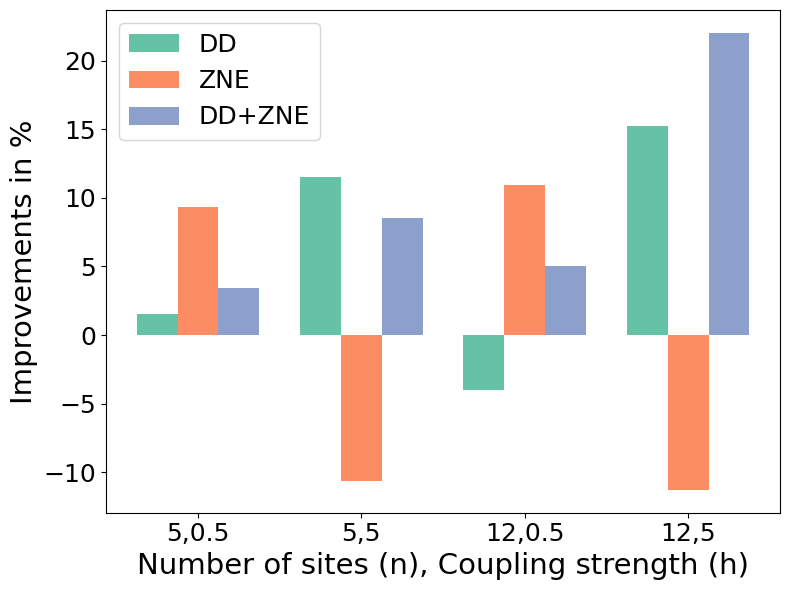

In [15]:
# 1. Prepare your 3 sets of 16 values
dd_values = [ddim[(n, h)] for (n, h) in product(num_sites, couplings)]
zne_values = [zneim[(n, h)] for (n, h) in product(num_sites, couplings)]
dd_zne_values = [ddzneim[(n, h)] for (n, h) in product(num_sites, couplings)]

# Labels for the 16 groups
groups = [f'{n},{h}' for (n, h) in product(num_sites, couplings)]

# 2. Set up positions
x = np.arange(len(groups))  # The label locations
width = 0.25  # The width of the individual bars

fig, ax = plt.subplots(figsize=(8, 6))

# 3. Create the bars
# We offset each bar by the width to keep them grouped
rects1 = ax.bar(x - width, dd_values, width, label='DD', color=color_dd)
rects2 = ax.bar(x, zne_values, width, label='ZNE', color=color_zne)
rects3 = ax.bar(x + width, dd_zne_values, width, label='DD+ZNE', color=color_dd_zne)

ax.set_xlabel('Number of sites (n), Coupling strength (h)', fontsize=21)
ax.set_ylabel('Improvements in %', fontsize=21)
# ax.set_title('Comparison of EM techniques for Heisenberg Hamiltonian simulation', fontsize=21)
ax.set_xticks(x)
ax.set_xticklabels(groups) # Rotated for better readability
ax.tick_params(axis='both', which='major', labelsize=18)
ax.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.savefig('heisenberg_evo.pdf')
plt.show()